# GPT-2 Loss Landscape Visualization

This notebook generates a 3D loss landscape for GPT-2 using the **filter-normalized random direction** method from:

> Li, H., Xu, Z., Taylor, G., Studer, C., & Goldstein, T. (2018).  
> *Visualizing the Loss Landscape of Neural Nets.* NeurIPS.

### Method
1. Load pretrained GPT-2 and freeze its parameters **Θ₀**.
2. Sample two random direction vectors **R₁**, **R₂** in parameter space.
3. **Filter-normalize** each direction so that for every weight tensor, the random direction has the same Frobenius norm as the original weights (this preserves per-layer scale).
4. Build a grid of **(α, β)** values and for each point compute **Θ_mod = Θ₀ + αR₁ + βR₂**.
5. Evaluate cross-entropy loss on a text dataset at each grid point.
6. Plot the resulting surface.

### Requirements
```
pip install torch transformers datasets matplotlib numpy
```

In [ ]:
# ── Install dependencies (uncomment if needed) ──
# !pip install torch transformers datasets matplotlib numpy

In [ ]:
import copy
import torch
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from mpl_toolkits.mplot3d import Axes3D
from transformers import GPT2LMHeadModel, GPT2Tokenizer
from datasets import load_dataset
from tqdm import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


## 1. Load Pretrained GPT-2

In [ ]:
model_name = "gpt2"  # 124M parameter model

tokenizer = GPT2Tokenizer.from_pretrained(model_name)
tokenizer.pad_token = tokenizer.eos_token

model = GPT2LMHeadModel.from_pretrained(model_name)
model.eval()
model.to(device)

print(f"Loaded {model_name} with {sum(p.numel() for p in model.parameters()):,} parameters")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

Loaded gpt2 with 124,439,808 parameters


## 2. Prepare Evaluation Data

We use a subset of WikiText-2 to evaluate cross-entropy loss at each grid point.  
Using more tokens gives smoother landscapes but takes longer.

In [ ]:
# ── Configuration ──
MAX_SEQ_LEN = 256    # context window per batch element
NUM_BATCHES = 8      # number of batches to average loss over
BATCH_SIZE = 4       # sequences per batch

# Load and tokenize wikitext-2
dataset = load_dataset("wikitext", "wikitext-2-raw-v1", split="test")
full_text = "\n".join([t for t in dataset["text"] if t.strip()])
tokens = tokenizer.encode(full_text, return_tensors="pt").squeeze(0)
print(f"Total tokens in eval set: {tokens.shape[0]:,}")

# Pre-chunk into batches for fast repeated evaluation
def make_batches(tokens, seq_len, batch_size, num_batches):
    """Slice token stream into fixed batches for reproducible loss evaluation."""
    total_needed = seq_len * batch_size * num_batches
    tokens = tokens[:total_needed]
    tokens = tokens.view(batch_size * num_batches, seq_len)
    batches = tokens.split(batch_size, dim=0)
    return batches[:num_batches]

eval_batches = make_batches(tokens, MAX_SEQ_LEN, BATCH_SIZE, NUM_BATCHES)
print(f"Prepared {len(eval_batches)} batches of shape {eval_batches[0].shape}")

README.md: 0.00B [00:00, ?B/s]

wikitext-2-raw-v1/test-00000-of-00001.pa(…):   0%|          | 0.00/733k [00:00<?, ?B/s]

wikitext-2-raw-v1/train-00000-of-00001.p(…):   0%|          | 0.00/6.36M [00:00<?, ?B/s]

wikitext-2-raw-v1/validation-00000-of-00(…):   0%|          | 0.00/657k [00:00<?, ?B/s]

Generating test split:   0%|          | 0/4358 [00:00<?, ? examples/s]

Generating train split:   0%|          | 0/36718 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/3760 [00:00<?, ? examples/s]

Token indices sequence length is longer than the specified maximum sequence length for this model (283287 > 1024). Running this sequence through the model will result in indexing errors


Total tokens in eval set: 283,287
Prepared 8 batches of shape torch.Size([4, 256])


## 3. Generate Filter-Normalized Random Directions

For each parameter tensor **W** in the model, a random direction **d** is drawn from a Gaussian, then normalized so that `‖d‖_F = ‖W‖_F`. This ensures each layer's direction has the same scale as its weights — critical for meaningful landscapes.

Following the Welch Labs visualization, we only perturb parameters in the **first half** of the transformer layers (the earlier layers produce more interesting landscape structure).

In [ ]:
def get_perturbable_params(model):
    """
    Return dict of {name: param} for parameters to perturb.
    We target weight matrices (dim >= 2) in the first half of transformer blocks,
    plus the token and position embeddings.
    """
    params = {}
    num_layers = model.config.n_layer
    half = num_layers // 2

    for name, param in model.named_parameters():
        # Always include embeddings
        if "wte" in name or "wpe" in name:
            params[name] = param
            continue
        # Include first-half transformer layers (weight matrices only)
        for layer_idx in range(half):
            prefix = f"transformer.h.{layer_idx}."
            if name.startswith(prefix) and param.dim() >= 2:
                params[name] = param
                break

    print(f"Perturbing {len(params)} parameter tensors "
          f"({sum(p.numel() for p in params.values()):,} params) "
          f"out of {sum(1 for _ in model.parameters())} total tensors")
    return params


def create_filter_normalized_direction(param_dict):
    """
    Create a random direction vector with filter normalization.
    For each tensor W, direction d is scaled so ‖d‖_F = ‖W‖_F.
    """
    direction = {}
    for name, param in param_dict.items():
        d = torch.randn_like(param)
        # Filter normalize: scale d to have same Frobenius norm as param
        param_norm = param.data.norm()
        d_norm = d.norm()
        if d_norm > 0:
            d = d * (param_norm / d_norm)
        direction[name] = d
    return direction


perturbable = get_perturbable_params(model)

# Cache original parameter values
theta_0 = {name: param.data.clone() for name, param in perturbable.items()}

# Generate two random directions
torch.manual_seed(42)  # for reproducibility
R1 = create_filter_normalized_direction(perturbable)
R2 = create_filter_normalized_direction(perturbable)

print("Random directions R1, R2 created.")

Perturbing 26 parameter tensors (81,851,136 params) out of 148 total tensors
Random directions R1, R2 created.


## 4. Loss Evaluation Function

In [ ]:
@torch.no_grad()
def evaluate_loss(model, batches):
    """Compute average cross-entropy loss over pre-built batches."""
    total_loss = 0.0
    for batch in batches:
        input_ids = batch.to(device)
        outputs = model(input_ids, labels=input_ids)
        total_loss += outputs.loss.item()
    return total_loss / len(batches)


def set_perturbed_params(model, theta_0, R1, R2, alpha, beta):
    """Set model parameters to Θ₀ + α·R₁ + β·R₂."""
    with torch.no_grad():
        for name, param in model.named_parameters():
            if name in theta_0:
                param.data.copy_(
                    theta_0[name] + alpha * R1[name] + beta * R2[name]
                )


def restore_params(model, theta_0):
    """Restore original parameters."""
    with torch.no_grad():
        for name, param in model.named_parameters():
            if name in theta_0:
                param.data.copy_(theta_0[name])


# Sanity check: loss at the origin
restore_params(model, theta_0)
origin_loss = evaluate_loss(model, eval_batches)
print(f"Loss at origin (pretrained weights): {origin_loss:.4f}")

`loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


Loss at origin (pretrained weights): 3.9607


## 5. Sweep the (α, β) Grid

This is the expensive step — we evaluate the model at every grid point.  

**Tuning tips:**
- `GRID_SIZE`: 21×21 is a good starting point (~7 min on GPU). Use 41×41 for publication quality.
- `RANGE`: controls how far from Θ₀ we explore. Start with 1.0; increase if the landscape looks flat.

In [ ]:
GRID_SIZE = 100   # number of points along each axis (21×21 = 441 evaluations)
RANGE = 1.0      # sweep α, β from -RANGE to +RANGE

alphas = np.linspace(-RANGE, RANGE, GRID_SIZE)
betas = np.linspace(-RANGE, RANGE, GRID_SIZE)

loss_grid = np.zeros((GRID_SIZE, GRID_SIZE))

total = GRID_SIZE * GRID_SIZE
print(f"Evaluating {total} grid points...")

with tqdm(total=total, desc="Loss landscape") as pbar:
    for i, alpha in enumerate(alphas):
        for j, beta in enumerate(betas):
            set_perturbed_params(model, theta_0, R1, R2, alpha, beta)
            loss_grid[i, j] = evaluate_loss(model, eval_batches)
            pbar.update(1)

# Restore original params
restore_params(model, theta_0)

print(f"\nLoss range: [{loss_grid.min():.3f}, {loss_grid.max():.3f}]")
print(f"Loss at center: {loss_grid[GRID_SIZE//2, GRID_SIZE//2]:.3f}")

Evaluating 10000 grid points...


Loss landscape: 100%|██████████| 10000/10000 [25:27<00:00,  6.55it/s]


Loss range: [4.045, 84.741]
Loss at center: 4.083


## 6. Plot the Loss Landscape

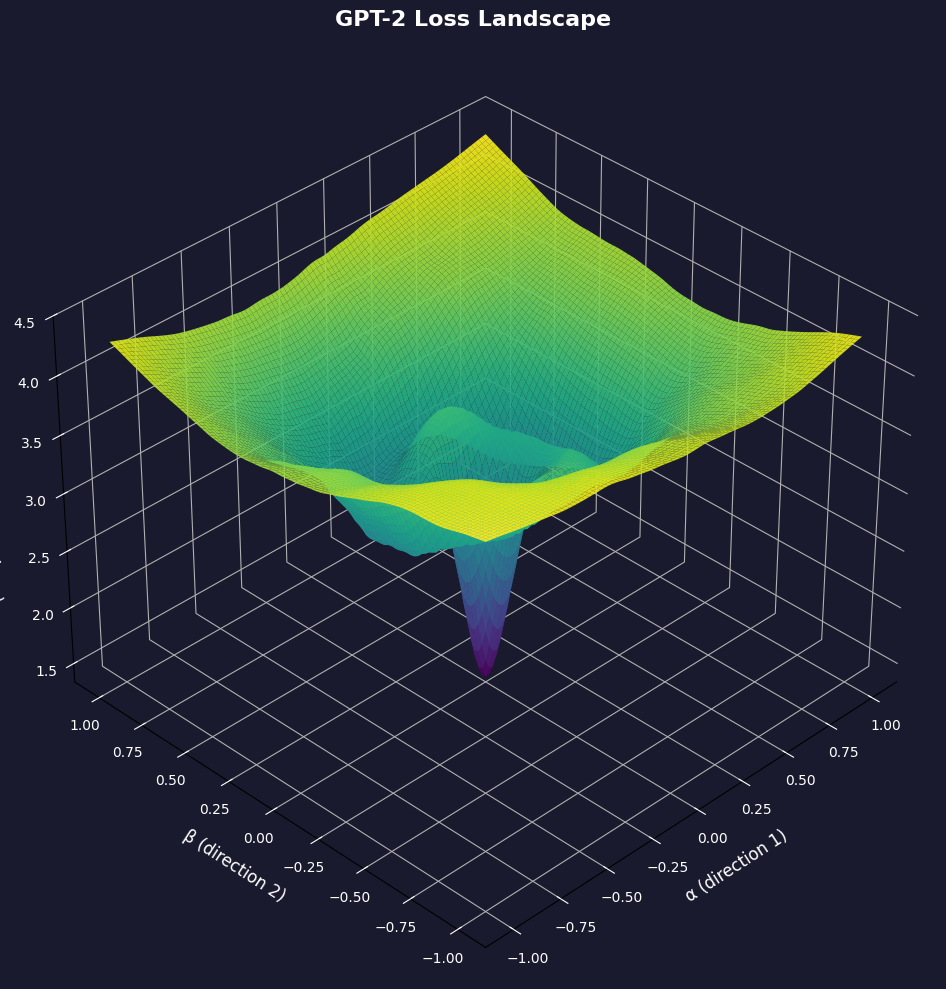

Saved to gpt2_loss_landscape.png


In [ ]:
# ── 3D Surface Plot (matching the Welch Labs aesthetic) ──

A, B = np.meshgrid(alphas, betas, indexing='ij')

fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')

# Log-scale the loss for better visual contrast (optional)
Z = np.log(loss_grid)

surf = ax.plot_surface(
    A, B, Z,
    cmap='viridis',
    edgecolor='none',
    alpha=0.95,
    rstride=1, cstride=1,
    antialiased=True,
)

ax.set_xlabel('α (direction 1)', fontsize=12, labelpad=10)
ax.set_ylabel('β (direction 2)', fontsize=12, labelpad=10)
ax.set_zlabel('log(Cross-Entropy Loss)', fontsize=12, labelpad=10)
ax.set_title('GPT-2 Loss Landscape', fontsize=16, fontweight='bold', pad=20)

# Style to match the dark theme
fig.patch.set_facecolor('#1a1a2e')
ax.set_facecolor('#1a1a2e')
ax.xaxis.pane.fill = False
ax.yaxis.pane.fill = False
ax.zaxis.pane.fill = False
ax.xaxis.pane.set_edgecolor('#1a1a2e')
ax.yaxis.pane.set_edgecolor('#1a1a2e')
ax.zaxis.pane.set_edgecolor('#1a1a2e')
ax.tick_params(colors='white')
ax.xaxis.label.set_color('white')
ax.yaxis.label.set_color('white')
ax.zaxis.label.set_color('white')
ax.title.set_color('white')

# Set viewing angle similar to the reference image
ax.view_init(elev=35, azim=225)

plt.tight_layout()
plt.savefig('gpt2_loss_landscape.png', dpi=200, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()
print("Saved to gpt2_loss_landscape.png")

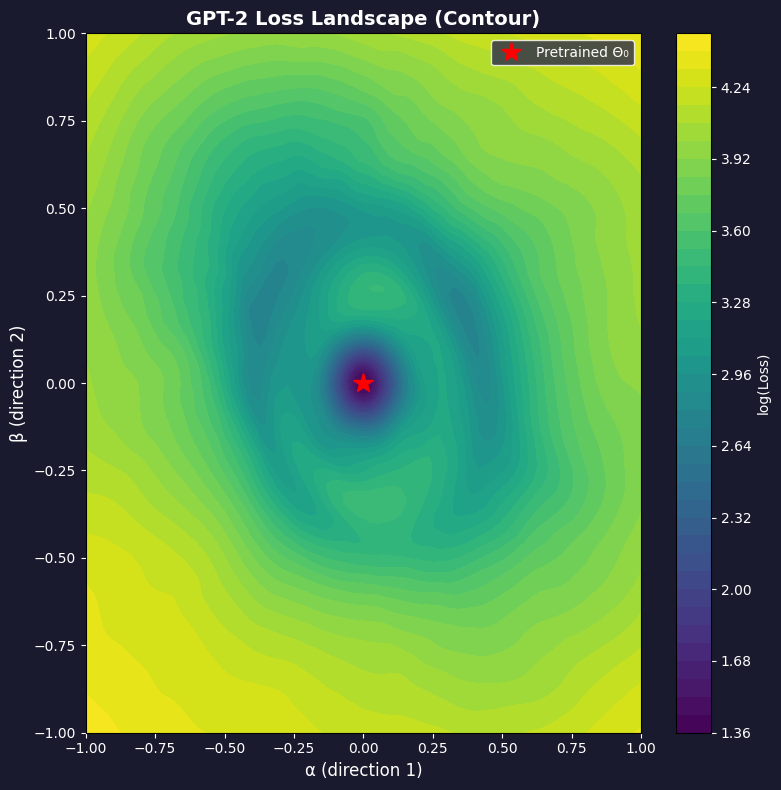

Saved to gpt2_loss_contour.png


In [ ]:
# ── 2D Contour Plot (top-down view) ──

fig, ax = plt.subplots(figsize=(8, 8))
fig.patch.set_facecolor('#1a1a2e')
ax.set_facecolor('#1a1a2e')

contour = ax.contourf(A, B, Z, levels=40, cmap='viridis')
cbar = plt.colorbar(contour, ax=ax, label='log(Loss)')
cbar.ax.yaxis.set_tick_params(color='white')
cbar.ax.yaxis.label.set_color('white')
plt.setp(plt.getp(cbar.ax.axes, 'yticklabels'), color='white')

# Mark the center (pretrained weights)
ax.plot(0, 0, 'r*', markersize=15, label='Pretrained Θ₀')
ax.legend(facecolor='#2a2a4e', edgecolor='white', labelcolor='white')

ax.set_xlabel('α (direction 1)', color='white', fontsize=12)
ax.set_ylabel('β (direction 2)', color='white', fontsize=12)
ax.set_title('GPT-2 Loss Landscape (Contour)', color='white',
             fontsize=14, fontweight='bold')
ax.tick_params(colors='white')

plt.tight_layout()
plt.savefig('gpt2_loss_contour.png', dpi=200, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()
print("Saved to gpt2_loss_contour.png")

In [ ]:
# ── Save raw data for later reuse ──
np.savez('gpt2_loss_landscape_data.npz',
         alphas=alphas, betas=betas, loss_grid=loss_grid)
print("Raw grid data saved to gpt2_loss_landscape_data.npz")

Raw grid data saved to gpt2_loss_landscape_data.npz


## 7. Higher-Resolution Variant (Optional)

Uncomment and run the cell below for a publication-quality 41×41 grid.  
Expect ~30 min on a single GPU.

In [ ]:
# GRID_SIZE_HQ = 41
# RANGE_HQ = 1.0
#
# alphas_hq = np.linspace(-RANGE_HQ, RANGE_HQ, GRID_SIZE_HQ)
# betas_hq = np.linspace(-RANGE_HQ, RANGE_HQ, GRID_SIZE_HQ)
# loss_grid_hq = np.zeros((GRID_SIZE_HQ, GRID_SIZE_HQ))
#
# with tqdm(total=GRID_SIZE_HQ**2, desc="HQ sweep") as pbar:
#     for i, alpha in enumerate(alphas_hq):
#         for j, beta in enumerate(betas_hq):
#             set_perturbed_params(model, theta_0, R1, R2, alpha, beta)
#             loss_grid_hq[i, j] = evaluate_loss(model, eval_batches)
#             pbar.update(1)
#
# restore_params(model, theta_0)
# np.savez('gpt2_loss_landscape_hq.npz',
#          alphas=alphas_hq, betas=betas_hq, loss_grid=loss_grid_hq)

---

## Notes

**Method:** We follow the filter-normalized random direction approach from [Li et al. (2018)](https://arxiv.org/abs/1712.09913). For each weight tensor **W**, the random direction **d** is rescaled so `‖d‖_F = ‖W‖_F`, preventing large layers from dominating the landscape.

**Partial perturbation:** Following the Welch Labs visualization, we only perturb parameters in the first half of the transformer layers plus embeddings. This produces more visually interesting landscapes — perturbing all layers tends to produce a more uniformly steep bowl.

**Tuning knobs:**
- `RANGE`: Increase to 2.0 or 3.0 to see more of the landscape. Decrease to 0.5 for finer detail near the optimum.
- `NUM_BATCHES` / `BATCH_SIZE`: More eval data = smoother surface but slower.
- `GRID_SIZE`: 21 is fast for exploration, 41+ for final plots.
- `MAX_SEQ_LEN`: Longer contexts give more stable loss estimates.

**Performance:** Each grid point requires a full forward pass over all eval batches. On an A100 GPU with the default settings (21×21 grid, 8 batches of 4×256 tokens), expect ~5–10 minutes total. CPU will be significantly slower (~1–2 hours).